# ASML and U.S. Market Drivers: Exploratory Data Analysis

## Objective
This notebook studies how **ASML's daily abnormal return** (relative to the **EURO STOXX 50**) co-moves with a set of external market signals.

The main idea is to separate **company-specific / sector-specific movement** from the broader European equity market, and then test which outside variables are most closely associated with that abnormal return.

## Drivers analysed
- **SOX**: Philadelphia Semiconductor Index
- **NDX**: Nasdaq-100
- **EUR/USD**
- **VIX** changes
- **U.S. 10Y Treasury yield** changes

## Main questions
1. Which external signals are most strongly related to ASML's abnormal daily return?
2. Are these relationships mainly **same-day** or do they show up with a lag?
3. Do the relationships weaken or strengthen across **low-VIX** and **high-VIX** regimes?
4. Are the correlations stable through time, especially around important 2025 market events?


## 1. Imports


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

## 2. Data download and feature construction

The analysis uses daily market data downloaded with `yfinance`.

### Download window
- Start: **2022-01-01**
- End: **2025-07-01**

### Construction choices
- For **price-based series** (ASML, EURO STOXX 50, SOX, NDX, EUR/USD), the notebook uses **log returns**.
- For **level-based series** (VIX and U.S. 10Y yield), the notebook uses **daily changes**.
- The target variable is

\[
\text{ASML abnormal return}_t
=
\text{ASML return}_t - \text{EURO STOXX 50 return}_t.
\]

This makes the target easier to read as ASML's performance **relative to the European benchmark** rather than as a raw stock return.


In [2]:
tickers = {
    "ASML": "ASML.AS",
    "ESTX50": "^STOXX50E",
    "SOX": "^SOX",
    "NDX": "^NDX",
    "EURUSD": "EURUSD=X",
    "VIX": "^VIX",
    "US10Y": "^TNX",
}

data = yf.download(
    list(tickers.values()),
    start="2022-01-01",
    end="2025-07-01",
)["Close"]

data.columns = tickers.keys()
print(data.head())

C:\Users\Anahit\AppData\Local\Temp\ipykernel_13592\1102720149.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), start = '2022-01-01', end = '2025-07-01')["Close"]
[*********************100%***********************]  7 of 7 completed

                  ASML    ESTX50           SOX          NDX       EURUSD  \
Date                                                                       
2022-01-03  675.432068  1.137346  16501.769531  4027.219971  4331.819824   
2022-01-04  655.795715  1.130224  16279.730469  4009.000000  4367.620117   
2022-01-05  645.785095  1.128363  15771.780273  3879.870117  4392.149902   
2022-01-06  633.849365  1.131350  15765.360352  3909.040039  4324.810059   
2022-01-07  640.009644  1.129688  15592.190430  3796.320068  4305.830078   

              VIX      US10Y  
Date                          
2022-01-03  1.628  16.600000  
2022-01-04  1.668  16.910000  
2022-01-05  1.705  19.730000  
2022-01-06  1.733  19.610001  
2022-01-07  1.771  18.760000  


In [3]:
# Price-based series: convert to daily log returns
log_returns = np.log(
    data[["ASML", "ESTX50", "SOX", "NDX", "EURUSD"]]
    / data[["ASML", "ESTX50", "SOX", "NDX", "EURUSD"]].shift(1)
)

# Level-based series: use daily changes
changes = data[["VIX", "US10Y"]].diff()

# Target: ASML relative to the broader European equity market
log_returns["ASML_abnormal"] = log_returns["ASML"] - log_returns["ESTX50"]

# Merge everything into one working table
eda_data = pd.concat([log_returns, changes], axis=1).dropna()

eda_data = eda_data.rename(
    columns={
        "ASML": "ASML_return",
        "ESTX50": "ESTX50_return",
        "SOX": "SOX_return",
        "NDX": "NDX_return",
        "EURUSD": "EURUSD_return",
        "VIX": "VIX_change",
        "US10Y": "US10Y_change",
    }
)

print(eda_data.head())

            ASML_return  ESTX50_return  SOX_return  NDX_return  EURUSD_return  \
Date                                                                            
2022-01-04    -0.029503      -0.006281   -0.013547   -0.004534       0.008231   
2022-01-05    -0.015383      -0.001649   -0.031699   -0.032740       0.005601   
2022-01-06    -0.018655       0.002644   -0.000407    0.007490      -0.015451   
2022-01-07     0.009672      -0.001470   -0.011045   -0.029260      -0.004398   
2022-01-10    -0.066214       0.005040    0.001425    0.002386      -0.015520   

            ASML_abnormal  VIX_change  US10Y_change  
Date                                                 
2022-01-04      -0.023222       0.040      0.309999  
2022-01-05      -0.013734       0.037      2.820000  
2022-01-06      -0.021299       0.028     -0.119999  
2022-01-07       0.011142       0.038     -0.850000  
2022-01-10      -0.071254       0.009      0.639999  


## 3. Descriptive behaviour of ASML abnormal returns

The first step is to understand the distribution of the target series:
- location and dispersion,
- skewness and tail behaviour,
- histogram shape,
- and the largest positive / negative abnormal-return days.


In [6]:
descript_stats = eda_data["ASML_abnormal"].describe()
descript_stats.head()

count    802.000000
mean       0.000037
std        0.025133
min       -0.168639
25%       -0.014036
Name: ASML_abnormal, dtype: float64

In [7]:
skew = eda_data["ASML_abnormal"].skew()
skew

-0.30828268977457113

In [8]:
kurt = eda_data["ASML_abnormal"].kurtosis()
kurt

3.7459851202237417

In [9]:
print("Descriptive stats for ASML abnormal return:")
print(descript_stats)
print(f"Skewness: {skew:.3f}")
print(f"Kurtosis: {kurt:.3f}")

# Interpretation guide:
# - Negative skewness suggests downside tail risk is somewhat heavier.
# - Positive excess kurtosis suggests fatter tails than a Gaussian benchmark.

Descriptive  stats for ASML abnormal return:
count    802.000000
mean       0.000037
std        0.025133
min       -0.168639
25%       -0.014036
50%        0.000056
75%        0.013491
max        0.099043
Name: ASML_abnormal, dtype: float64
Skewness: -0.308
Kurtosis: 3.746


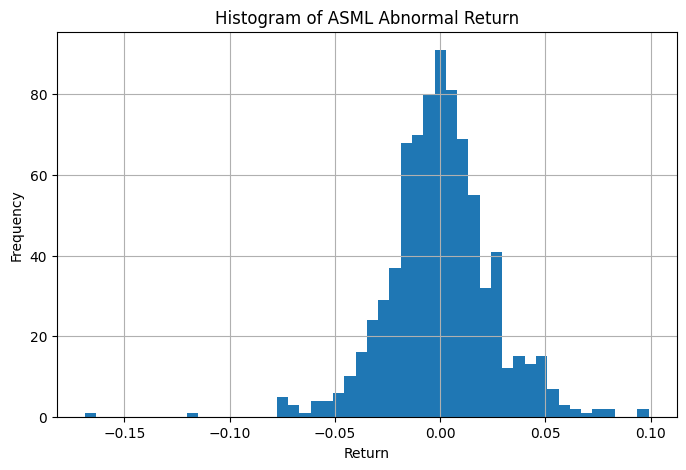

In [10]:
plt.figure(figsize=(8, 5))
eda_data["ASML_abnormal"].hist(bins=50)
plt.title("Histogram of ASML Abnormal Return")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

In [11]:
print("\nTop 5 negative abnormal returns:")
print(eda_data["ASML_abnormal"].nsmallest(5))


Top 5 negative abnormal returns:
Date
2024-10-15   -0.168639
2024-07-17   -0.115865
2025-01-27   -0.077588
2022-01-24   -0.075443
2022-05-09   -0.073788
Name: ASML_abnormal, dtype: float64


In [12]:
print("\nTop 5 positive abnormal returns:")
print(eda_data["ASML_abnormal"].nlargest(5))


Top 5 positive abnormal returns
Date
2022-11-10    0.099043
2024-01-24    0.094777
2024-06-05    0.080224
2025-01-06    0.079736
2022-10-19    0.076590
Name: ASML_abnormal, dtype: float64


## 4. Autocorrelation of the target series

Autocorrelation checks whether today's abnormal return is linearly related to its own recent past.

A 20-lag ACF is used here, which is roughly one trading month. If the bars beyond lag 0 remain inside the confidence band, then the evidence for short-run linear predictability from the target's own history is weak.


<Figure size 800x500 with 0 Axes>

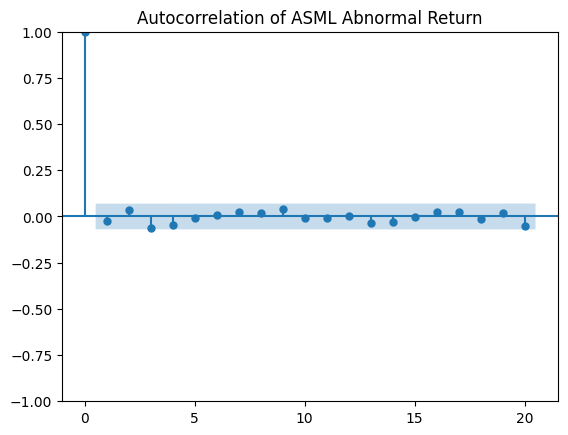

In [13]:
plt.figure(figsize=(8, 5))
plot_acf(eda_data["ASML_abnormal"], lags=20)
plt.title("Autocorrelation of ASML Abnormal Return")
plt.show()

The ACF plot suggests **little meaningful linear serial dependence** beyond lag 0. That points to a series that behaves much closer to **news-driven noise** than to a smooth momentum process.

This matters because it means that any explanatory power is more likely to come from **external drivers** than from the target's own recent path.


## 5. Contemporaneous driver correlations

Next, the notebook studies **same-day co-movement** between ASML's abnormal return and each external signal.


In [14]:
drivers = ["SOX_return", "NDX_return", "EURUSD_return", "VIX_change", "US10Y_change"]

corrs = (
    eda_data[["ASML_abnormal"] + drivers]
    .corr()
    .loc[drivers, "ASML_abnormal"]
    .sort_values(ascending=False)
)

print("Contemporaneous correlations with ASML_abnormal (sorted):")
print(corrs)

Contemporaneous correlations with ASML_abnormal (sorted):
EURUSD_return    0.694116
NDX_return       0.548639
SOX_return       0.476971
VIX_change      -0.021124
US10Y_change    -0.251084
Name: ASML_abnormal, dtype: float64


The strongest same-day relationships are with:
- **EUR/USD return**
- **Nasdaq-100 return**
- **SOX return**

The U.S. 10Y change is moderately negative, while same-day VIX changes are much weaker in this simple correlation view.

So the first pass already suggests that ASML's relative performance is much more tightly connected to **equity / FX drivers** than to immediate VIX shocks.


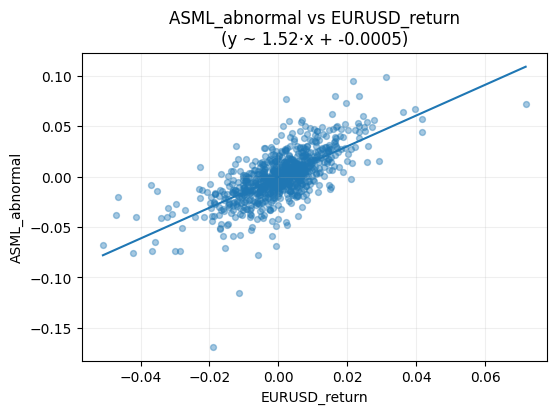

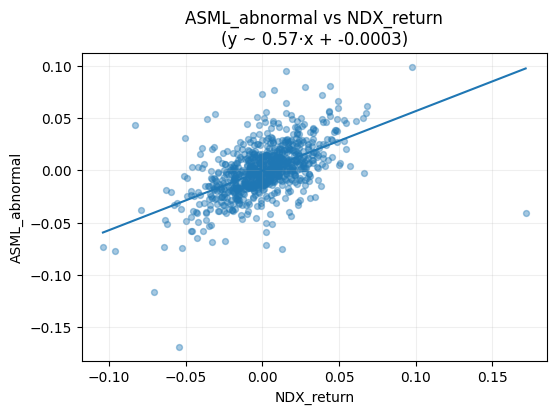

In [15]:
# Plot the two strongest contemporaneous drivers by absolute correlation
top2 = corrs.reindex(corrs.abs().sort_values(ascending=False).index[:2]).index.tolist()

for x in top2:
    xvals = eda_data[x].values
    yvals = eda_data["ASML_abnormal"].values

    plt.figure(figsize=(6, 4))
    plt.scatter(xvals, yvals, alpha=0.4, s=18)

    b1, b0 = np.polyfit(xvals, yvals, 1)
    xs = np.linspace(xvals.min(), xvals.max(), 100)
    plt.plot(xs, b1 * xs + b0)

    plt.title(f"ASML_abnormal vs {x}\n(y ~ {b1:.2f}·x + {b0:.4f})")
    plt.xlabel(x)
    plt.ylabel("ASML_abnormal")
    plt.grid(alpha=0.2)
    plt.show()

## 6. Outlier robustness check

To see whether the correlation ranking is driven by a few extreme days, the notebook trims the top and bottom 1% of `ASML_abnormal` and recomputes the same-day correlations.


In [17]:
low_q, high_q = 0.01, 0.99
low_val = eda_data["ASML_abnormal"].quantile(low_q)
high_val = eda_data["ASML_abnormal"].quantile(high_q)

trimmed = eda_data[
    (eda_data["ASML_abnormal"] >= low_val) & (eda_data["ASML_abnormal"] <= high_val)
]

print(f"Original sample size: {len(eda_data)}")
print(f"Trimmed sample size: {len(trimmed)}")

Original sample size: 802
Trimmed sample size: 784


In [18]:
corrs_trimmed = trimmed[drivers].corrwith(trimmed["ASML_abnormal"]).sort_values(ascending=False)

print("\nCorrelations after trimming:")
print(corrs_trimmed)


Correlations after trimming:
EURUSD_return    0.682366
NDX_return       0.511522
SOX_return       0.453540
VIX_change      -0.052241
US10Y_change    -0.216661
dtype: float64


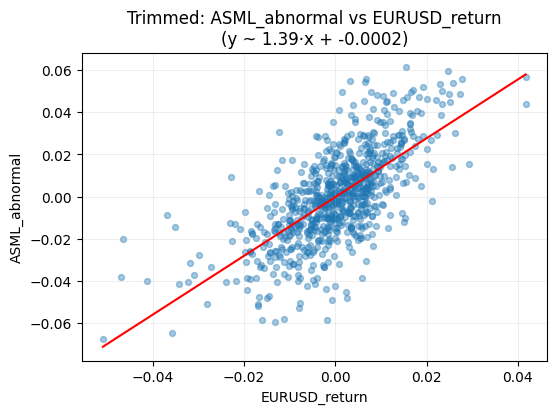

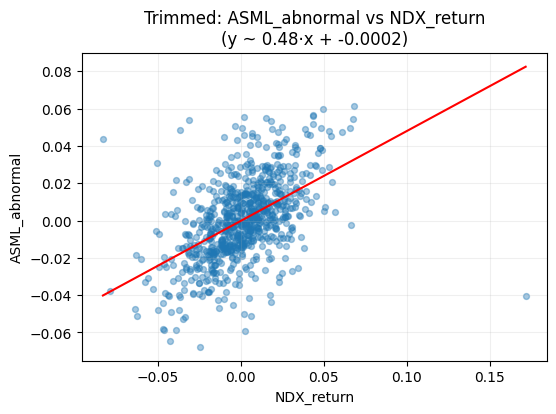

In [19]:
# Re-plot the two strongest drivers after trimming the most extreme ASML days
top2_trimmed = corrs_trimmed.abs().nlargest(2).index.tolist()

for x in top2_trimmed:
    xvals = trimmed[x].values
    yvals = trimmed["ASML_abnormal"].values

    plt.figure(figsize=(6, 4))
    plt.scatter(xvals, yvals, alpha=0.4, s=18)

    b1, b0 = np.polyfit(xvals, yvals, 1)
    xs = np.linspace(xvals.min(), xvals.max(), 100)
    plt.plot(xs, b1 * xs + b0, color="red")

    plt.title(f"Trimmed: ASML_abnormal vs {x}\n(y ~ {b1:.2f}·x + {b0:.4f})")
    plt.xlabel(x)
    plt.ylabel("ASML_abnormal")
    plt.grid(alpha=0.2)
    plt.show()

The trimmed-sample exercise keeps the same broad ranking. That is useful because it suggests the main correlation story is **not just an artifact of a few very large ASML days**.


## 7. Lagged relationships

Now the focus shifts from **same-day association** to **one-day lagged correlation**. This is closer to a weak predictive check: do yesterday's market moves help explain today's ASML abnormal return?


In [20]:
for col in drivers:
    eda_data[f"{col}_lag1"] = eda_data[col].shift(1)

lagged_corrs = (
    eda_data[[f"{col}_lag1" for col in drivers]]
    .corrwith(eda_data["ASML_abnormal"])
    .sort_values(ascending=False)
)

print(lagged_corrs)

SOX_return_lag1       0.145320
NDX_return_lag1       0.134325
VIX_change_lag1       0.082343
EURUSD_return_lag1   -0.080867
US10Y_change_lag1    -0.116752
dtype: float64


The lagged correlations are much smaller than the contemporaneous ones. So the evidence here points more toward **co-movement** than toward a strong short-horizon predictive structure.


## 8. VIX-regime analysis

The notebook next splits the sample by the **level of VIX**:
- **Low-VIX regime**: bottom 20%
- **High-VIX regime**: top 20%

This helps test whether the ASML-driver relationship changes in calm versus stressed market environments.


In [21]:
eda_data["VIX_level"] = data["VIX"].reindex(eda_data.index)

low_thr = eda_data["VIX_level"].quantile(0.20)
high_thr = eda_data["VIX_level"].quantile(0.80)

low_reg = eda_data[eda_data["VIX_level"] <= low_thr]
high_reg = eda_data[eda_data["VIX_level"] >= high_thr]

print(f"Low-VIX n={len(low_reg)}, High-VIX n={len(high_reg)}")

low_clean = low_reg[["ASML_abnormal"] + drivers].dropna()
high_clean = high_reg[["ASML_abnormal"] + drivers].dropna()

low_corrs = low_clean[drivers].corrwith(low_clean["ASML_abnormal"]).sort_values(ascending=False)
high_corrs = high_clean[drivers].corrwith(high_clean["ASML_abnormal"]).sort_values(ascending=False)

print("\nCorrelations in LOW-VIX regime:")
print(low_corrs)
print("\nCorrelations in HIGH-VIX regime:")
print(high_corrs)

Low-VIX n=161, High-VIX n=161

Correlations in LOW-VIX regime:
EURUSD_return    0.785771
NDX_return       0.563114
SOX_return       0.524983
VIX_change       0.036829
US10Y_change    -0.436028
dtype: float64

Correlations in HIGH-VIX regime:
EURUSD_return    0.606447
NDX_return       0.268329
SOX_return       0.153403
US10Y_change     0.054635
VIX_change      -0.018073
dtype: float64


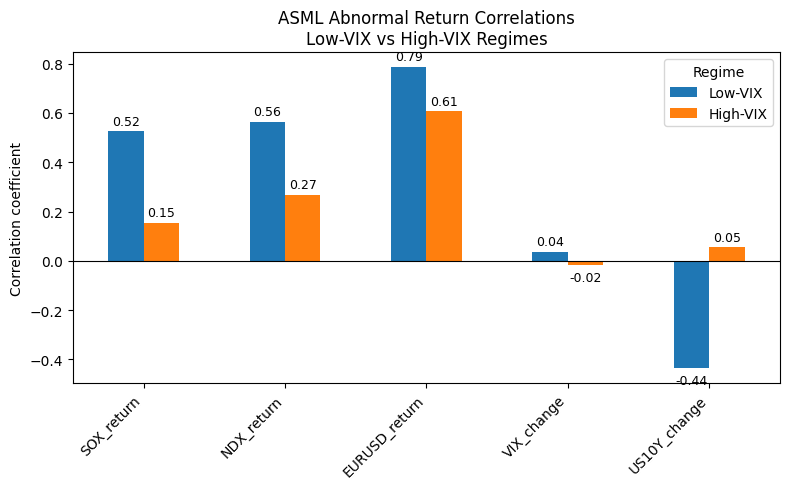

In [22]:
regime_corrs = pd.DataFrame({
    "Low-VIX": low_corrs,
    "High-VIX": high_corrs,
}).reindex(drivers)

ax = regime_corrs.plot(kind="bar", figsize=(8, 5))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("ASML Abnormal Return Correlations\nLow-VIX vs High-VIX Regimes")
plt.ylabel("Correlation coefficient")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Regime")
plt.tight_layout()

for container in ax.containers:
    for bar in container:
        y = bar.get_height()
        offset = 0.015 if y >= 0 else -0.025
        ax.annotate(
            f"{y:.2f}",
            (bar.get_x() + bar.get_width() / 2, y + offset),
            ha="center",
            va="bottom" if y >= 0 else "top",
            fontsize=9,
        )

plt.show()

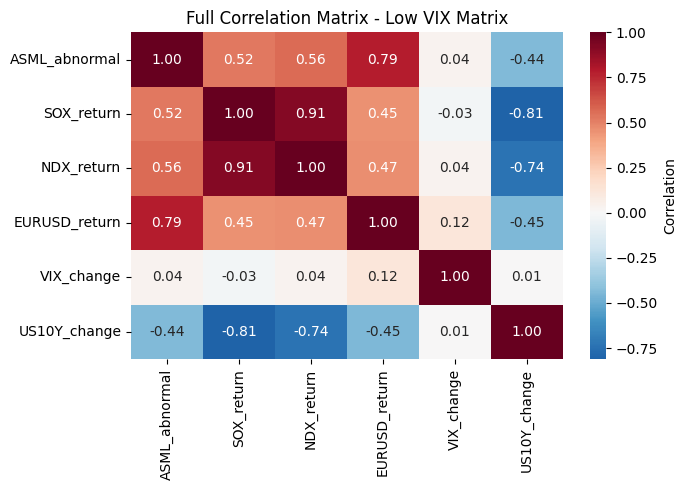

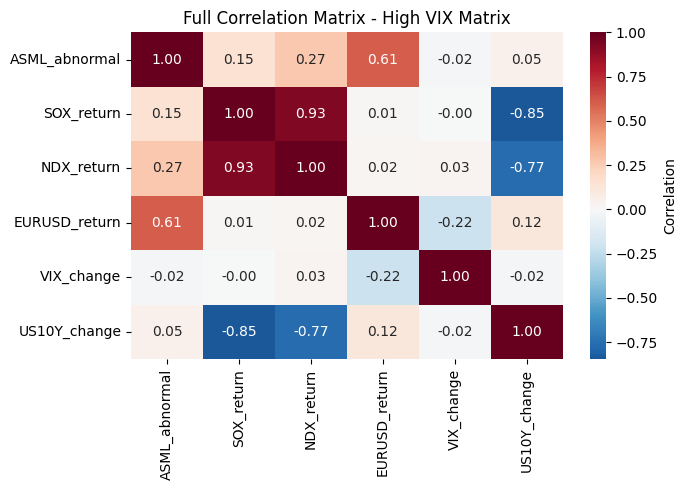

In [23]:
low_corr_matrix = low_clean[["ASML_abnormal"] + drivers].corr()
high_corr_matrix = high_clean[["ASML_abnormal"] + drivers].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    low_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "Correlation"},
)
plt.title("Full Correlation Matrix - Low VIX")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(
    high_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "Correlation"},
)
plt.title("Full Correlation Matrix - High VIX")
plt.tight_layout()
plt.show()

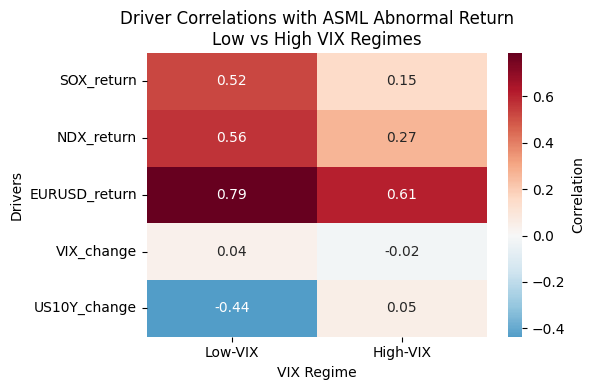

In [24]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    regime_corrs,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "Correlation"},
)
plt.title("Driver Correlations with ASML Abnormal Return\nLow vs High VIX Regimes")
plt.ylabel("Drivers")
plt.xlabel("VIX regime")
plt.tight_layout()
plt.show()

A useful pattern emerges here: the low-VIX regime tends to show **stronger and cleaner positive co-movement** with EUR/USD, NDX, and SOX, while those relationships weaken materially in the high-VIX regime.

That suggests the external-driver structure is **state dependent**: when markets are stressed, correlations become noisier and less stable.


## 9. Rolling correlations and event windows

Static full-sample correlations can hide a lot of time variation. The next block therefore studies **rolling correlations** using 90-day and 120-day windows.

Special attention is given to three 2025 dates used as event markers in the notebook:
- **2025-01-20**: U.S. inauguration
- **2025-04-02**: tariff news
- **2025-04-15**: tariff implementation


In [25]:
windows = [90, 120]
event_markers = [
    ("Inauguration", pd.Timestamp("2025-01-20")),
    ("Tariff News", pd.Timestamp("2025-04-02")),
    ("Tariff Implementation", pd.Timestamp("2025-04-15")),
]

if not np.issubdtype(eda_data.index.dtype, np.datetime64):
    eda_data = eda_data.copy()
    eda_data.index = pd.to_datetime(eda_data.index)

In [26]:
def rolling_corr_df(df, target_col, drivers, window):
    out = {}
    for d in drivers:
        out[d] = df[target_col].rolling(window).corr(df[d]).rename(d)
    return pd.concat(out.values(), axis=1)

In [27]:
roll_corrs = {w: rolling_corr_df(eda_data, "ASML_abnormal", drivers, w) for w in windows}

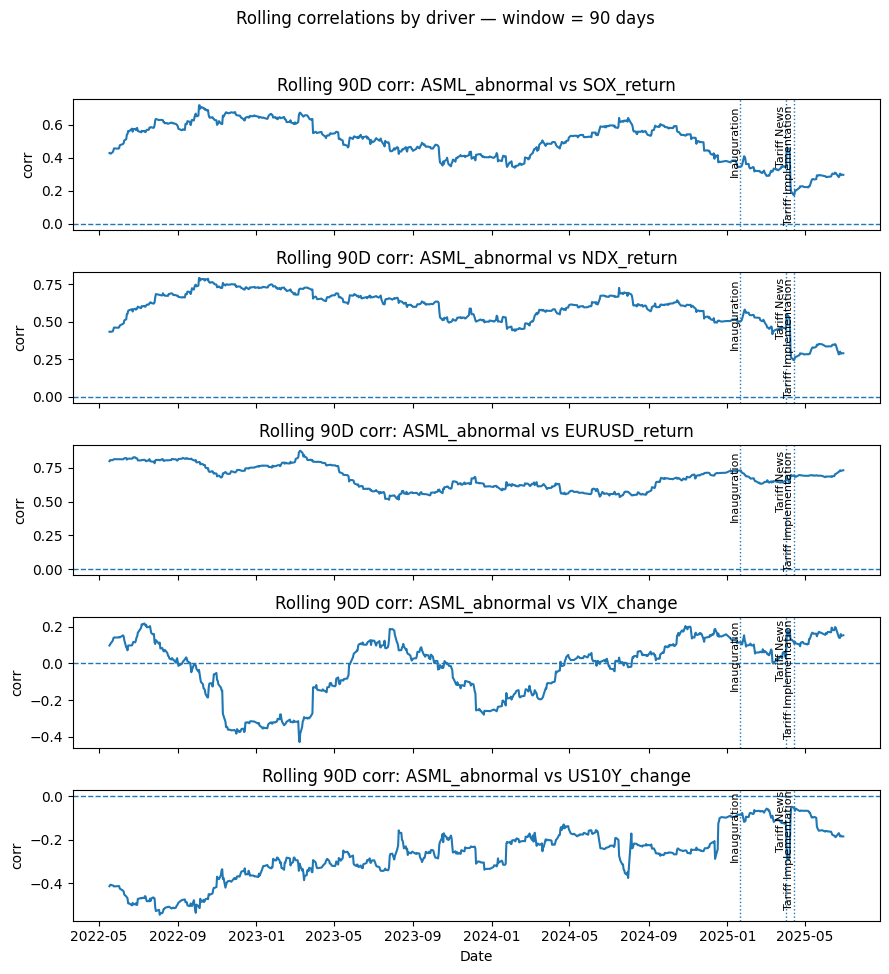

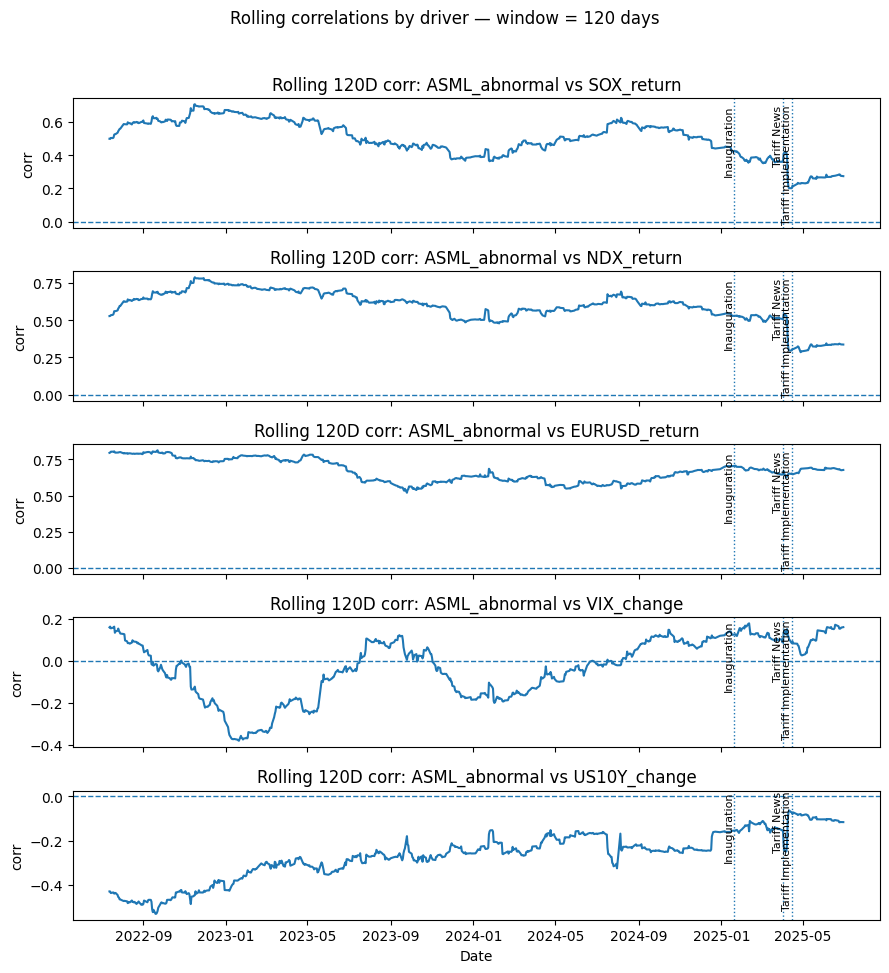

In [28]:
for w in windows:
    dfw = roll_corrs[w]
    n = len(drivers)

    fig, axes = plt.subplots(n, 1, figsize=(9, 1.9 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, d in zip(axes, drivers):
        sns.lineplot(data=dfw[d], ax=ax)
        ax.axhline(0, ls="--", lw=1)
        ax.set_ylabel("corr")
        ax.set_title(f"Rolling {w}D corr: ASML_abnormal vs {d}")

        for label, when in event_markers:
            if dfw.index.min() <= when <= dfw.index.max():
                ax.axvline(when, ls=":", lw=1)
                ax.text(when, ax.get_ylim()[1] * 0.95, label, rotation=90, va="top", ha="right", fontsize=8)

    axes[-1].set_xlabel("Date")
    fig.suptitle(f"Rolling correlations by driver — window = {w} days", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

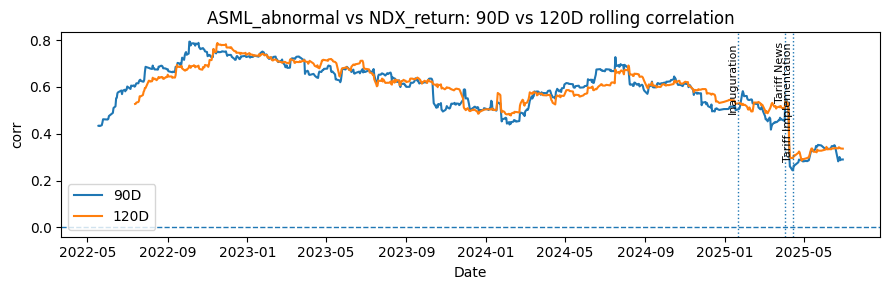

In [29]:
driver_to_compare = "NDX_return"

plt.figure(figsize=(9, 3))
for w in windows:
    sns.lineplot(data=roll_corrs[w][driver_to_compare], label=f"{w}D")

plt.axhline(0, ls="--", lw=1)

for label, when in event_markers:
    if roll_corrs[windows[0]].index.min() <= when <= roll_corrs[windows[0]].index.max():
        plt.axvline(when, ls=":", lw=1)
        plt.text(when, plt.gca().get_ylim()[1] * 0.95, label, rotation=90, va="top", ha="right", fontsize=8)

plt.title(f"ASML_abnormal vs {driver_to_compare}: 90D vs 120D rolling correlation")
plt.xlabel("Date")
plt.ylabel("corr")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
if not np.issubdtype(eda_data.index.dtype, np.datetime64):
    eda_data = eda_data.copy()
    eda_data.index = pd.to_datetime(eda_data.index)

inaug = pd.Timestamp("2025-01-20")
tariff_ann = pd.Timestamp("2025-04-02")
tariff_impl = pd.Timestamp("2025-04-15")

zoom_start = pd.Timestamp("2025-03-01")
zoom_end = pd.Timestamp("2025-05-31")

focus_drivers = ["SOX_return", "NDX_return"]

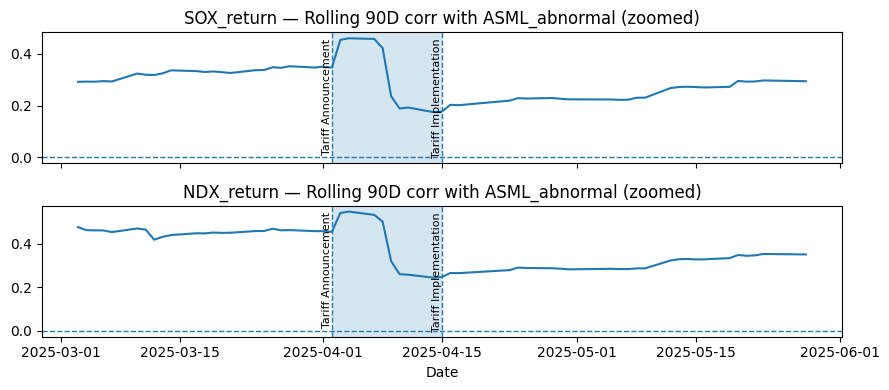

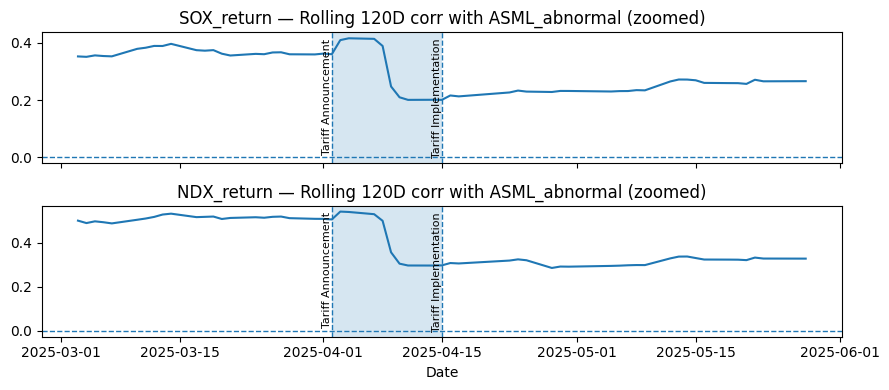

In [31]:
for w in [90, 120]:
    dfw = roll_corrs[w].loc[zoom_start:zoom_end, focus_drivers]
    n = len(focus_drivers)

    fig, axes = plt.subplots(n, 1, figsize=(9, 2.0 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, d in zip(axes, focus_drivers):
        sns.lineplot(x=dfw.index, y=dfw[d].values, ax=ax)
        ax.axhline(0, ls="--", lw=1)
        ax.set_title(f"{d} — Rolling {w}D corr with ASML_abnormal (zoomed)")
        ax.axvspan(tariff_ann, tariff_impl, alpha=0.18, zorder=0)

        for label, when in [
            ("Inauguration", inaug),
            ("Tariff Announcement", tariff_ann),
            ("Tariff Implementation", tariff_impl),
        ]:
            if dfw.index.min() <= when <= dfw.index.max():
                ax.axvline(when, ls="--", lw=1)
                ax.text(when, ax.get_ylim()[1] * 0.95, label, rotation=90, va="top", ha="right", fontsize=8)

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

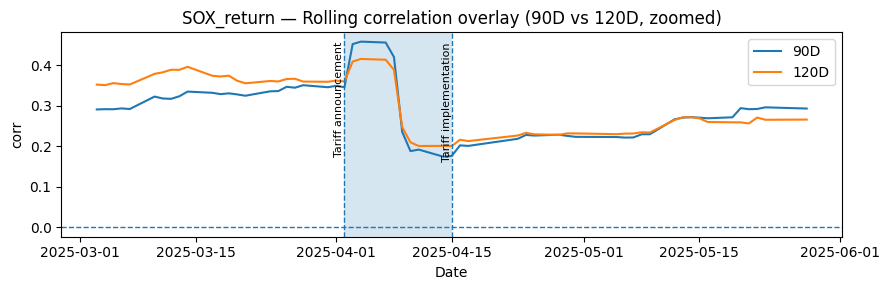

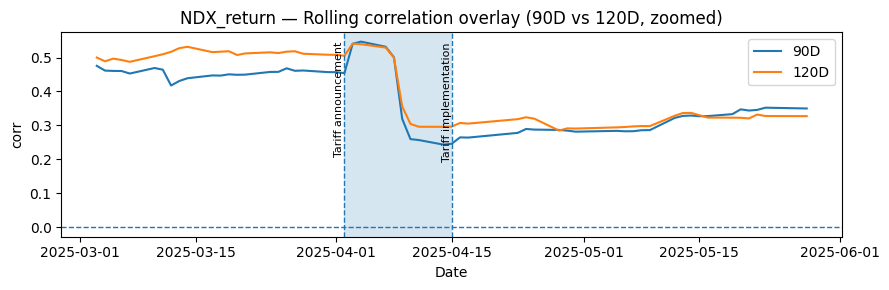

In [32]:
for d in focus_drivers:
    s90 = roll_corrs[90][d].loc[zoom_start:zoom_end]
    s120 = roll_corrs[120][d].loc[zoom_start:zoom_end]

    plt.figure(figsize=(9, 3))
    sns.lineplot(x=s90.index, y=s90.values, label="90D")
    sns.lineplot(x=s120.index, y=s120.values, label="120D")
    plt.axhline(0, ls="--", lw=1)

    plt.axvspan(tariff_ann, tariff_impl, alpha=0.18, zorder=0)
    for label, when in [
        ("Inauguration", inaug),
        ("Tariff announcement", tariff_ann),
        ("Tariff implementation", tariff_impl),
    ]:
        if s90.index.min() <= when <= s90.index.max():
            plt.axvline(when, ls="--", lw=1)
            plt.text(when, plt.gca().get_ylim()[1] * 0.95, label, rotation=90, va="top", ha="right", fontsize=8)

    plt.title(f"{d} — Rolling correlation overlay (90D vs 120D, zoomed)")
    plt.xlabel("Date")
    plt.ylabel("corr")
    plt.legend()
    plt.tight_layout()
    plt.show()

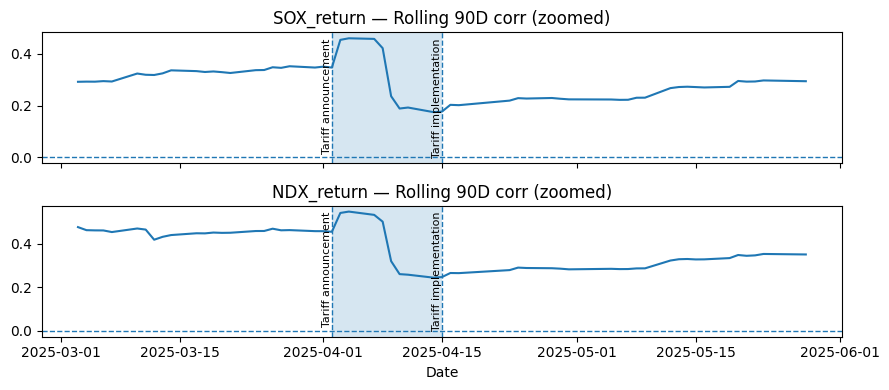

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

for ax, d in zip(axes, focus_drivers):
    s90 = roll_corrs[90][d].loc[zoom_start:zoom_end]
    sns.lineplot(x=s90.index, y=s90.values, ax=ax)
    ax.axhline(0, ls="--", lw=1)
    ax.axvspan(tariff_ann, tariff_impl, alpha=0.18, zorder=0)

    for label, when in [
        ("Inauguration", inaug),
        ("Tariff announcement", tariff_ann),
        ("Tariff implementation", tariff_impl),
    ]:
        if s90.index.min() <= when <= s90.index.max():
            ax.axvline(when, ls="--", lw=1)
            ax.text(when, ax.get_ylim()[1] * 0.95, label, rotation=90, va="top", ha="right", fontsize=8)

    ax.set_title(f"{d} — Rolling 90D corr (zoomed)")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

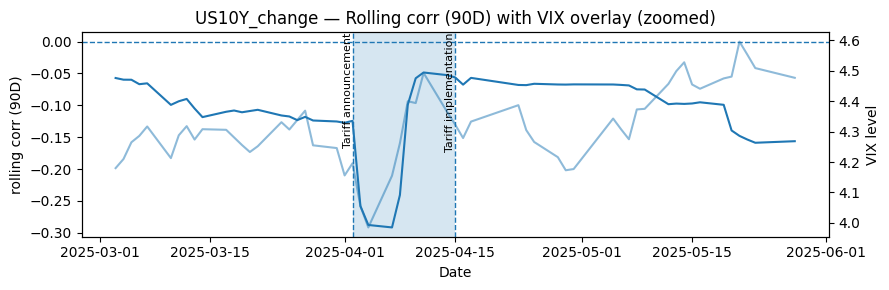

In [45]:
d = "US10Y_change"
s90 = roll_corrs[90][d].loc[zoom_start:zoom_end]
vix = eda_data["VIX_level"].loc[zoom_start:zoom_end].dropna()

fig, ax1 = plt.subplots(figsize=(9, 3))
sns.lineplot(x=s90.index, y=s90.values, ax=ax1)
ax1.axhline(0, ls="--", lw=1)
ax1.axvspan(tariff_ann, tariff_impl, alpha=0.18, zorder=0)
ax1.set_ylabel("rolling corr (90D)")
ax1.set_title(f"{d} — Rolling corr (90D) with VIX overlay (zoomed)")

ax2 = ax1.twinx()
sns.lineplot(x=vix.index, y=vix.values, ax=ax2, alpha=0.5)
ax2.set_ylabel("VIX level")

for label, when in [
    ("Inauguration", inaug),
    ("Tariff announcement", tariff_ann),
    ("Tariff implementation", tariff_impl),
]:
    if s90.index.min() <= when <= s90.index.max():
        ax1.axvline(when, ls="--", lw=1)
        ax1.text(when, ax1.get_ylim()[1] * 0.95, label, rotation=90, va="top", ha="right", fontsize=8)

plt.tight_layout()
plt.show()

These plots are there to answer a more realistic market question: even if a driver matters on average, **does it matter consistently through time**, or only during specific windows?

That is especially relevant for ASML because semiconductor and trade-sensitive names can experience abrupt changes in correlation structure around macro and policy events.


## 10. Pearson vs Spearman robustness

Because rolling Pearson correlation can be sensitive to outliers and linearity assumptions, the notebook also compares it with a rolling **Spearman** version for the main focus drivers.


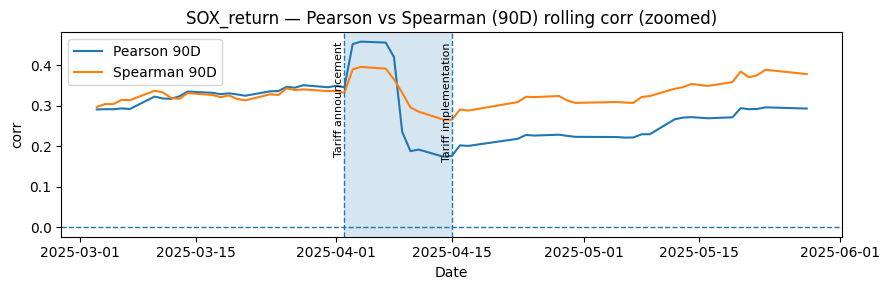

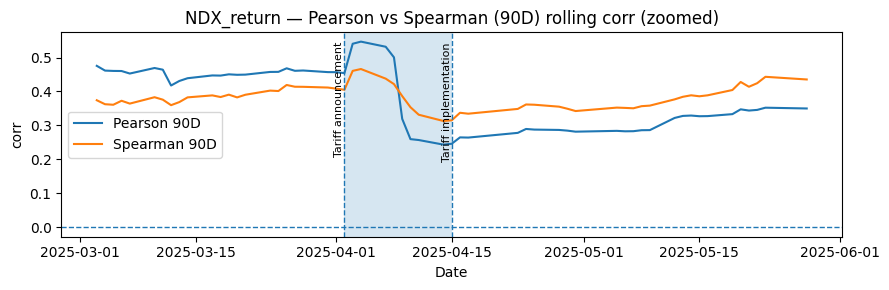

In [54]:
def rolling_spearman(df, target, drv, W, min_obs=None):
    """
    Exact rolling Spearman correlation between df[target] and df[drv],
    right-aligned, using a window of size W.
    """
    a = df[target].to_numpy()
    b = df[drv].to_numpy()
    n = len(df)
    out = np.full(n, np.nan, dtype=float)

    if min_obs is None:
        min_obs = W

    for i in range(W - 1, n):
        sa = a[i - W + 1 : i + 1]
        sb = b[i - W + 1 : i + 1]
        m = ~np.isnan(sa) & ~np.isnan(sb)

        if m.sum() >= min_obs:
            ra = pd.Series(sa[m]).rank(method="average").to_numpy()
            rb = pd.Series(sb[m]).rank(method="average").to_numpy()
            out[i] = np.corrcoef(ra, rb)[0, 1]

    return pd.Series(out, index=df.index, dtype=float)


# Ensure event dates are Timestamps
inaug = pd.to_datetime(inaug)
tariff_ann = pd.to_datetime(tariff_ann)
tariff_impl = pd.to_datetime(tariff_impl)

for d in focus_drivers:
    pear = roll_corrs[90][d].loc[zoom_start:zoom_end]
    spear = rolling_spearman(eda_data, "ASML_abnormal", d, 90).loc[zoom_start:zoom_end]

    plt.figure(figsize=(9, 3))
    sns.lineplot(x=pear.index, y=pear.values, label="Pearson 90D")
    sns.lineplot(x=spear.index, y=spear.values, label="Spearman 90D")
    plt.axhline(0, ls="--", lw=1)

    plt.axvspan(tariff_ann, tariff_impl, alpha=0.18, zorder=0)
    for label, when in [
        ("Inauguration", inaug),
        ("Tariff announcement", tariff_ann),
        ("Tariff implementation", tariff_impl),
    ]:
        if pear.index.min() <= when <= pear.index.max():
            plt.axvline(when, ls="--", lw=1)
            plt.text(
                when,
                plt.gca().get_ylim()[1] * 0.95,
                label,
                rotation=90,
                va="top",
                ha="right",
                fontsize=8,
            )

    plt.title(f"{d} — Pearson vs Spearman (90D) rolling corr (zoomed)")
    plt.xlabel("Date")
    plt.ylabel("corr")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 11. Lead-lag profiles

Finally, the notebook computes correlations across lags from **-5 to +5** trading days.

Interpretation:
- **k > 0**: the driver leads ASML
- **k < 0**: ASML leads the driver
- **k = 0**: same-day association


In [40]:
if not np.issubdtype(eda_data.index.dtype, np.datetime64):
    eda_data = eda_data.copy()
    eda_data.index = pd.to_datetime(eda_data.index)

target_col = "ASML_abnormal"
max_lag = 5
min_obs = 60

In [41]:
def lag_corr_profile(y: pd.Series, x: pd.Series, max_lag: int = 5, min_obs: int = 60) -> pd.Series:
    lags = range(-max_lag, max_lag + 1)
    out = {}

    for k in lags:
        xs = x.shift(k)
        pair = pd.concat([y, xs], axis=1).dropna()
        out[k] = pair.iloc[:, 0].corr(pair.iloc[:, 1]) if len(pair) >= min_obs else np.nan

    return pd.Series(out, name=x.name)

In [42]:
y = eda_data[target_col]
lag_profiles = {
    d: lag_corr_profile(y, eda_data[d], max_lag=max_lag, min_obs=min_obs)
    for d in drivers
}
lag_df = pd.DataFrame(lag_profiles)
lag_df

,SOX_return,NDX_return,EURUSD_return,VIX_change,US10Y_change
-5,0.020368,0.017782,0.003992,-0.072666,-0.046477
-4,0.008011,-0.012515,0.016178,-0.079127,0.020920
-3,-0.028951,-0.029765,-0.056087,-0.015835,0.031784
-2,0.025810,0.020445,0.019634,-0.043928,0.002023
-1,-0.001508,0.003278,-0.048488,-0.030394,-0.009622
0,0.476971,0.548639,0.694116,-0.021124,-0.251084
1,0.145320,0.134325,-0.080867,0.082343,-0.116752
2,-0.024372,-0.017783,0.000597,-0.041106,0.060245
3,-0.012484,-0.017719,-0.035365,-0.088187,-0.035369
4,-0.040401,-0.030468,-0.028148,-0.026737,-0.010097


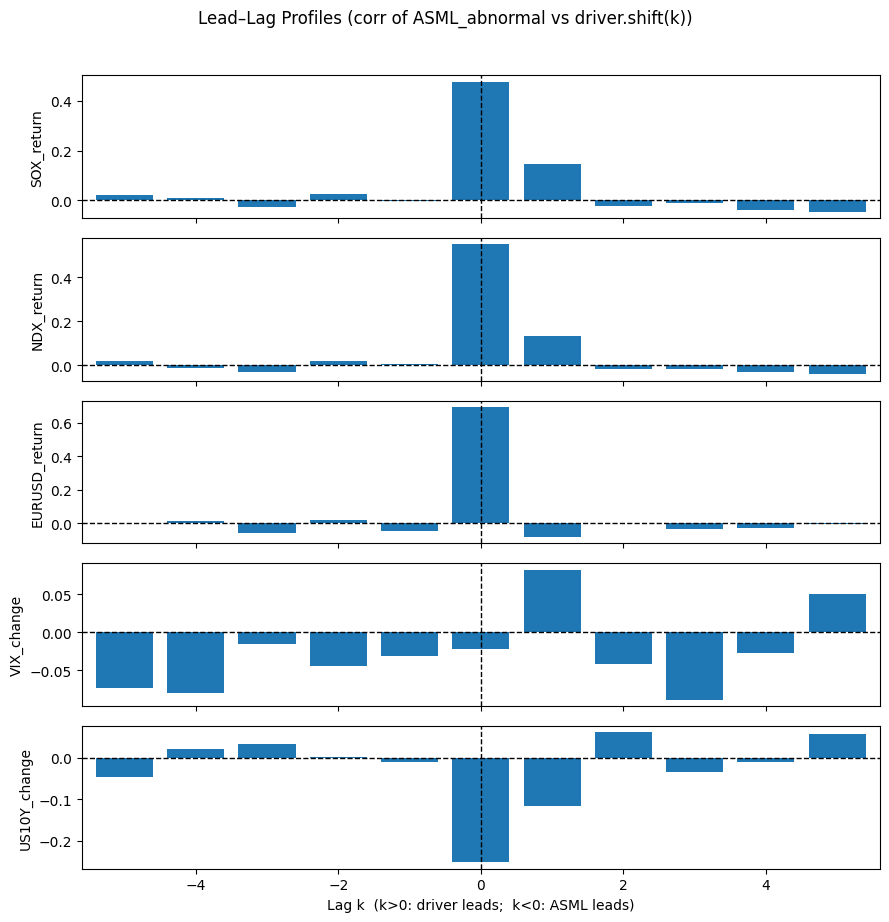

In [43]:
n = len(drivers)
fig, axes = plt.subplots(n, 1, figsize=(9, 1.8 * n), sharex=True)

if n == 1:
    axes = [axes]

lags = np.arange(-max_lag, max_lag + 1)

for ax, d in zip(axes, drivers):
    vals = lag_df[d].values
    ax.bar(lags, vals, width=0.8)
    ax.axhline(0, ls="--", lw=1, color="black")
    ax.axvline(0, ls="--", lw=1, color="black")
    ax.set_ylabel(d)
    ax.set_xlim(lags.min() - 0.6, lags.max() + 0.6)

axes[-1].set_xlabel("Lag k  (k > 0: driver leads; k < 0: ASML leads)")
fig.suptitle("Lead–Lag Profiles (corr of ASML_abnormal vs driver.shift(k))", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

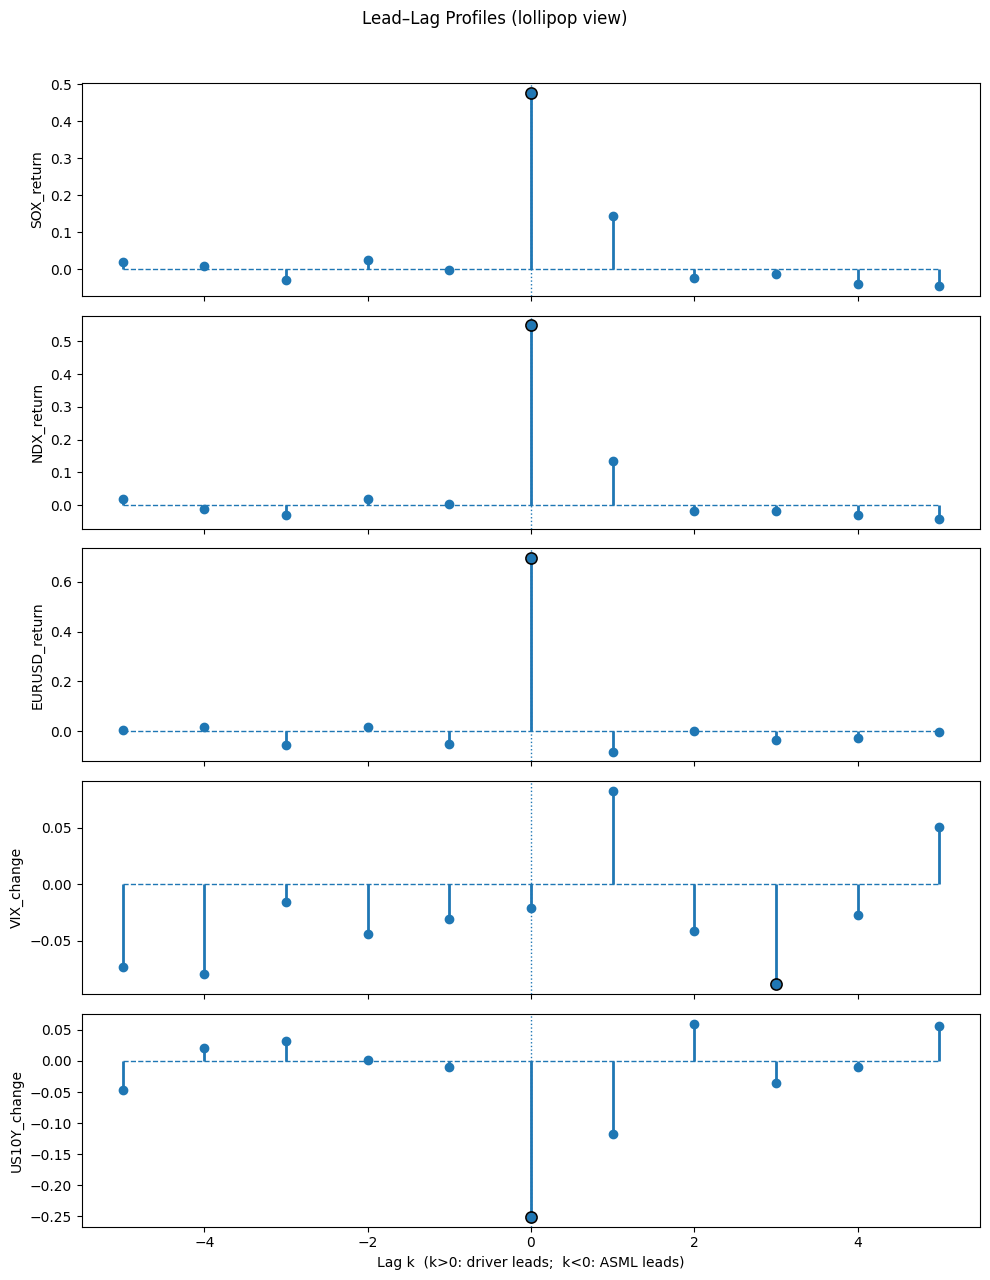

In [44]:
lags = lag_df.index.values
n = len(lag_df.columns)

fig, axes = plt.subplots(n, 1, figsize=(10, 2.5 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, drv in zip(axes, lag_df.columns):
    vals = lag_df[drv].values
    ax.hlines(y=0, xmin=lags.min(), xmax=lags.max(), linestyles="--", linewidth=1)
    ax.vlines(lags, 0, vals, linewidth=2)
    ax.plot(lags, vals, "o", ms=6)
    ax.axvline(0, ls=":", lw=1)

    k_best = lags[np.nanargmax(np.abs(vals))]
    v_best = vals[np.nanargmax(np.abs(vals))]
    ax.plot(k_best, v_best, "o", ms=8, mfc="none", mec="black", mew=1.2)
    ax.set_ylabel(drv)

axes[-1].set_xlabel("Lag k  (k > 0: driver leads; k < 0: ASML leads)")
fig.suptitle("Lead–Lag Profiles (lollipop view)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 12. Main findings

### What the notebook suggests
- **Contemporaneous** relationships are much stronger than **lagged** ones.
- The most important same-day drivers are **EUR/USD**, **Nasdaq-100**, and **SOX**.
- The target series itself shows **little autocorrelation**, which weakens a simple time-series predictability story.
- In **low-VIX** periods, ASML's co-movement with the main equity / FX drivers is stronger and clearer.
- In **high-VIX** periods, these relationships weaken, which points to more unstable stress-period behaviour.
- The lead-lag profiles reinforce the idea that the strongest links happen at or near **lag 0**, not far in advance.

### Portfolio value
This is stronger than a basic stock notebook because it goes beyond summary charts:
- it defines a benchmark-relative target,
- checks robustness to outliers,
- tests regime dependence,
- studies time variation with rolling windows,
- and examines lead-lag structure explicitly.
